# Data Exploration 1: Data Import & Initial Exploration
```
Course: ENV 700 - Environmental Data Exploration
Authors: John Fay & Luana Lima
```


## Overview

Data exploration begins by reading data into a coding environment, usually as a **Pandas dataframe**. Before analyzing a dataset, however, we need to understand its contents, structure, provenance, data types, missing values, and any other issues that should be addressed before analysis.

This notebook walks through an intentional, reproducible workflow for importing and conducting an initial exploration of USGS streamflow data.

## Lesson objectives

By the end of this notebook, you should be able to:

- Start exploration of a dataset by familiarizing yourself with the **data's provenance**.
- Set up a **reproducible notebook** using packages and relative paths.
- Explain, at a basic level, how **arrays and dataframes** organize data in Python.
- **Read a CSV** file into a Pandas dataframe.
- **Inspect dataframe** structure, records, columns, data types, unique values, and summary statistics.
- **Rename columns** using clear and meaningful field names.
- Identify **missing values** and evaluate whether dropping records is appropriate.
- Control **data types** during import.
- Parse **date fields** and extract date components.
- Explore values in **categorical fields**. 
- **Save a processed dataset** without modifying the raw data.


---
## 1. Get to know your dataset
Before using a dataset, take a moment to familiarize yourself with its provenance. 
* Who collected the data? ("primary" vs "secondary" data)
* For what reason were the data collected? 
* What might be appropriate or inappropropriate uses of the data? 
* Could the data include any biases - intentional or not - that might influence your results?   

Typically, this begins by looking at any metadata documents associated with the data... 

👉 **For this exercise, we'll be using the `USGS_Site02085000_Flow_Raw.csv` dataset. Review its metadata document (`USGS_Site02085000_Flow_README.pdf`).**

---
## 2. Project setup

In reproducible data analysis, notebooks should make it clear which packages are required and where input and output files are located. We will use:

- `pathlib.Path` for project-relative file paths.
- `numpy` for a brief look at arrays, the basic building blocks behind many scientific Python tools.
- `pandas` for tabular data import, inspection, and cleaning.

**Practice principle:** raw data should be treated as read-only. Any cleaned or modified data should be saved separately, usually in a `data/processed` folder.


### Import packages

In [1]:
# Import packages
from pathlib import Path
import numpy as np
import pandas as pd

### [Set project paths](https://www.w3schools.com/python/ref_module_pathlib.asp)

This notebook assumes it is being run from a notebook folder located one level below the project root. If your project has a different structure, adjust `project_fldr` accordingly.


In [5]:
# Set project folders using relative paths
project_fldr = Path.cwd().parent
raw_fldr = project_fldr / "data" / "raw"
processed_fldr = project_fldr / "data" / "processed"

print("Project folder:", project_fldr)
print("Raw data folder:", raw_fldr)
print("Processed data folder:", processed_fldr)


Project folder: c:\Users\sjh104\EDE 700\ENV700
Raw data folder: c:\Users\sjh104\EDE 700\ENV700\data\raw
Processed data folder: c:\Users\sjh104\EDE 700\ENV700\data\processed


In [6]:
# Set the path to the raw USGS data file
raw_file = raw_fldr / "USGS_Site02085000_Flow_Raw.csv"

# Confirm the file exists before trying to import it
print(raw_file)
print("File exists:", raw_file.exists())


c:\Users\sjh104\EDE 700\ENV700\data\raw\USGS_Site02085000_Flow_Raw.csv
File exists: True


**Checkpoint**

If `File exists` returns `False`, stop here and check your project folder structure before continuing.


---
## ✳️Brief foundation: arrays and dataframes



Before importing the streamflow file, it helps to know the two core data structures we will use repeatedly.

◾ An **array** is an ordered collection of values. In scientific Python, arrays are commonly used for numerical data because they support fast, element-by-element calculations. The **NumPy** package provides the most common array structure. We use the [**Numpy**](https://numpy.org/) package for working with arrays. ([Numpy cheat sheet](https://assets.datacamp.com/blog_assets/Numpy_Python_Cheat_Sheet.pdf).)

◾ A **dataframe** is a rectangular table with rows and columns. In [**Pandas**](https://pandas.pydata.org/), each column is a labeled sequence of values, and the whole dataframe behaves much like a spreadsheet table that can be inspected, filtered, cleaned, summarized, and plotted using code. ([Pandas cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf).)

We'll begin with the basics of these two data structures and learn more as we go. 

#### 💠[Arrays](https://numpy.org/doc/stable/user/quickstart.html#the-basics)
* Similar to lists, but all items must have the same data type.
* Can have multiple *dimensions*
* Support *vectorized* operations, which speeds computation time

In [7]:
# A NumPy array stores values in order
flow_values = np.array([12.4, 15.1, 13.8, 18.6])

# Arrays support element-wise calculations
flow_values * 1000

array([12400., 15100., 13800., 18600.])

##### 1-Dimension = *vector*

In [8]:
# Create a vector
a_vector = np.array([1,2,3,10,20,30])
print(a_vector)

[ 1  2  3 10 20 30]


In [9]:
#Extracting items from a vector
a_vector[1]

np.int64(2)

In [10]:
#Vector methods
a_vector.sum()

np.int64(66)

##### 2-dimensions = *matrix*

In [11]:
# Create a matrix
a_matrix = np.array([[1,2,3],[10,20,30]])
print(a_matrix)

[[ 1  2  3]
 [10 20 30]]


In [12]:
# Extracting items from a matrix
a_matrix[0,1]

np.int64(2)

In [13]:
# Matrix methods - the axis property (0=row, 1=column)
a_matrix.sum(axis=0)

array([11, 22, 33])

##### \>2-dimensions = *ndarray*

In [14]:
cube = np.array([
    [[1, 2], [3, 4]], 
    [[5, 6], [7, 8]]
])
print(cube.shape)
print(cube.ndim)

(2, 2, 2)
3


>**A quick demonstration: the perfomance boost of *vectorization***  
A comparison of how long it takes to iterate through 1 million numbers and compute their square, first with a Python list object, then with a Numpy array.

In [15]:
# The time module allows us to time how long processes take 
import time

# Using a list...
numbers = list(range(1_000_000))   # Create a list of 1 million numbers
start = time.time()                # Start the timer
result = []                        # Create a list to hold result values
for x in numbers:                  # Iterate through the 1m numbers
    result.append(x * 2)           # Add to the result list
loop_time = time.time() - start    # End the timer

# Using a Numpy array
arr = np.arange(1_000_000)         # Create an array with the same 1 million numbers
start = time.time()                # Start the timer
result = arr * 2                   # Compute the squares
numpy_time = time.time() - start   # End the timer

# Compare results
print(f'Loop time: {loop_time:.4f} seconds')
print(f'NumPy time: {numpy_time:.4f} seconds')

Loop time: 0.1312 seconds
NumPy time: 0.0152 seconds


### 💠[Dataframes](https://pandas.pydata.org/docs/getting_started/intro_tutorials/01_table_oriented.html)
Dataframes resemble a table: 2 dimensions with rows and columns. 
* Columns are labeled. 
* Rows are indexed. 
* All values in a column share the same data type (*i.e. they are Numpy vectors*)

In [16]:
# A Pandas dataframe stores data in named columns
example_flow = pd.DataFrame({
    "site_no": ["02085000", "02085000", "02085000", "02085000"],
    "day": ["Monday", "Tuesday", "Wednesday", "Thursday"],
    "flow_cfs": flow_values
})

example_flow

,site_no,day,flow_cfs
0,02085000,Monday,12.4
1,02085000,Tuesday,15.1
2,02085000,Wednesday,13.8
3,02085000,Thursday,18.6


Notice the difference in structure: the array is a single sequence of values, while the dataframe preserves field names and related variables together. Most environmental datasets we use in this course will be imported as dataframes.

---
## [3. Import the raw data](https://pandas.pydata.org/docs/user_guide/io.html#csv-text-files)

Pandas can read many file formats. For comma-separated values files, use `pd.read_csv()`.

The first import is intentionally simple. This gives us a chance to inspect what Pandas infers automatically before we start making decisions about field names, data types, and dates.


In [17]:
# Read the raw CSV file into a dataframe
USGS_flow_raw = pd.read_csv(raw_file)

# Show the first few records
USGS_flow_raw.head()


,agency_cd,site_no,datetime,165986_00060_00001,165986_00060_00001_cd,165987_00060_00002,165987_00060_00002_cd,84936_00060_00003,84936_00060_00003_cd,84937_00065_00001,84937_00065_00001_cd,84938_00065_00002,84938_00065_00002_cd,84939_00065_00003,84939_00065_00003_cd
0,USGS,2085000,1928-01-01,NaN,NaN,NaN,NaN,74.0,A,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,2085000,1928-01-02,NaN,NaN,NaN,NaN,61.0,A,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,2085000,1928-01-03,NaN,NaN,NaN,NaN,56.0,A,NaN,NaN,NaN,NaN,NaN,NaN
3,USGS,2085000,1928-01-04,NaN,NaN,NaN,NaN,54.0,A,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,2085000,1928-01-05,NaN,NaN,NaN,NaN,48.0,A,NaN,NaN,NaN,NaN,NaN,NaN


**What should you notice?**

Look at the column names, the first few values, and whether the columns are easy to interpret. Are the field names meaningful without consulting metadata?


> Optional tool note: interactive dataframe viewers such as the Data Wrangler extension in VS Code can be helpful for quick inspection. They are useful for exploration, but they do not replace reproducible code cells.


---
## [4. Inspect the dataframe structure](https://pandas.pydata.org/docs/user_guide/basics.html#attributes-and-underlying-data)

Before making any changes to the dataset, we want inspect its basic structure. Properties to examine:
- How many records and fields are in the dataset?
- Which fields are numeric?
- Which fields appear to be identifiers, dates, or categorical values?
- Are any columns missing many values?
- Do the minimum, maximum, or mean values look plausible?

In [18]:
# Number of rows and columns
USGS_flow_raw.shape


(30848, 15)

In [19]:
# Column names
USGS_flow_raw.columns


Index(['agency_cd', 'site_no', 'datetime', '165986_00060_00001',
       '165986_00060_00001_cd', '165987_00060_00002', '165987_00060_00002_cd',
       '84936_00060_00003', '84936_00060_00003_cd', '84937_00065_00001',
       '84937_00065_00001_cd', '84938_00065_00002', '84938_00065_00002_cd',
       '84939_00065_00003', '84939_00065_00003_cd'],
      dtype='str')

In [20]:
# Data types, non-null counts, and memory use
USGS_flow_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 30848 entries, 0 to 30847
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   agency_cd              30848 non-null  str    
 1   site_no                30848 non-null  int64  
 2   datetime               30848 non-null  str    
 3   165986_00060_00001     5348 non-null   float64
 4   165986_00060_00001_cd  5348 non-null   str    
 5   165987_00060_00002     5348 non-null   float64
 6   165987_00060_00002_cd  5348 non-null   str    
 7   84936_00060_00003      30848 non-null  float64
 8   84936_00060_00003_cd   30848 non-null  str    
 9   84937_00065_00001      5461 non-null   float64
 10  84937_00065_00001_cd   5461 non-null   str    
 11  84938_00065_00002      5461 non-null   float64
 12  84938_00065_00002_cd   5461 non-null   str    
 13  84939_00065_00003      11161 non-null  float64
 14  84939_00065_00003_cd   11161 non-null  str    
dtypes: float64(6)

In [21]:
# Summary statistics for numeric columns
USGS_flow_raw.describe()


,site_no,165986_00060_00001,165987_00060_00002,84936_00060_00003,84937_00065_00001,84938_00065_00002,84939_00065_00003
count,30848.0,5348.000000,5348.000000,30848.000000,5461.000000,5461.000000,11161.000000
mean,2085000.0,88.147554,30.462292,59.668283,2.123613,1.735719,1.987142
std,0.0,282.801800,61.329289,158.730953,1.416646,0.587740,0.919247
min,2085000.0,0.260000,0.090000,0.020000,0.890000,0.840000,0.870000
25%,2085000.0,7.230000,4.380000,9.200000,1.490000,1.380000,1.500000
50%,2085000.0,21.150000,12.600000,24.000000,1.830000,1.650000,1.810000
75%,2085000.0,59.800000,34.800000,53.325000,2.310000,2.030000,2.210000
max,2085000.0,4730.000000,1460.000000,8180.000000,17.020000,9.190000,15.040000


---
## [5. Rename and document fields](https://pandas.pydata.org/docs/user_guide/basics.html#renaming-mapping-labels)

The raw column names come from the source data. For analysis, we often want clearer field names. Instead of changing the raw file, we create a cleaned dataframe object with more meaningful column names.

The list below is based on the dataset metadata. Good field names should be readable, consistent, and easy to use in code.


In [23]:
# Define readable column names based on the USGS metadata
flow_columns = [
    "agency_cd", "site_no", "datetime",
    "discharge_max", "discharge_max_approval",
    "discharge_min", "discharge_min_approval",
    "discharge_mean", "discharge_mean_approval",
    "gage_height_max", "gage_height_max_approval",
    "gage_height_min", "gage_height_min_approval",
    "gage_height_mean", "gage_height_mean_approval"
]

# Create a working copy with updated column names
USGS_flow_data = USGS_flow_raw.copy()
USGS_flow_data.columns = flow_columns

USGS_flow_data.tail()


,agency_cd,site_no,datetime,discharge_max,discharge_max_approval,discharge_min,discharge_min_approval,discharge_mean,discharge_mean_approval,gage_height_max,gage_height_max_approval,gage_height_min,gage_height_min_approval,gage_height_mean,gage_height_mean_approval
30843,USGS,2085000,2026-06-06,NaN,NaN,NaN,NaN,4.76,P,NaN,NaN,NaN,NaN,1.55,P
30844,USGS,2085000,2026-06-07,NaN,NaN,NaN,NaN,4.71,P,NaN,NaN,NaN,NaN,1.55,P
30845,USGS,2085000,2026-06-08,NaN,NaN,NaN,NaN,4.51,P,NaN,NaN,NaN,NaN,1.54,P
30846,USGS,2085000,2026-06-09,NaN,NaN,NaN,NaN,4.38,P,NaN,NaN,NaN,NaN,1.53,P
30847,USGS,2085000,2026-06-10,NaN,NaN,NaN,NaN,4.60,P,NaN,NaN,NaN,NaN,1.54,P


In [24]:
# Confirm the updated field names
USGS_flow_data.columns


Index(['agency_cd', 'site_no', 'datetime', 'discharge_max',
       'discharge_max_approval', 'discharge_min', 'discharge_min_approval',
       'discharge_mean', 'discharge_mean_approval', 'gage_height_max',
       'gage_height_max_approval', 'gage_height_min',
       'gage_height_min_approval', 'gage_height_mean',
       'gage_height_mean_approval'],
      dtype='str')

##### 🔥 Knowledge Check
Choose one column and write a plain-language description of what it represents. Use the README or metadata associated with the dataset if needed.

> Your answer:


---
## [6. View records from different parts of the dataframe](https://pandas.pydata.org/docs/user_guide/basics.html)

`head()`, `tail()`, and `sample()` let us inspect different records without printing the whole dataframe.


In [25]:
# First two records
USGS_flow_data.head(2)


,agency_cd,site_no,datetime,discharge_max,discharge_max_approval,discharge_min,discharge_min_approval,discharge_mean,discharge_mean_approval,gage_height_max,gage_height_max_approval,gage_height_min,gage_height_min_approval,gage_height_mean,gage_height_mean_approval
0,USGS,2085000,1928-01-01,NaN,NaN,NaN,NaN,74.0,A,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,2085000,1928-01-02,NaN,NaN,NaN,NaN,61.0,A,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Last five records
USGS_flow_data.tail()


,agency_cd,site_no,datetime,discharge_max,discharge_max_approval,discharge_min,discharge_min_approval,discharge_mean,discharge_mean_approval,gage_height_max,gage_height_max_approval,gage_height_min,gage_height_min_approval,gage_height_mean,gage_height_mean_approval
30843,USGS,2085000,2026-06-06,NaN,NaN,NaN,NaN,4.76,P,NaN,NaN,NaN,NaN,1.55,P
30844,USGS,2085000,2026-06-07,NaN,NaN,NaN,NaN,4.71,P,NaN,NaN,NaN,NaN,1.55,P
30845,USGS,2085000,2026-06-08,NaN,NaN,NaN,NaN,4.51,P,NaN,NaN,NaN,NaN,1.54,P
30846,USGS,2085000,2026-06-09,NaN,NaN,NaN,NaN,4.38,P,NaN,NaN,NaN,NaN,1.53,P
30847,USGS,2085000,2026-06-10,NaN,NaN,NaN,NaN,4.60,P,NaN,NaN,NaN,NaN,1.54,P


In [27]:
# Three random records
USGS_flow_data.sample(3, random_state=42)


,agency_cd,site_no,datetime,discharge_max,discharge_max_approval,discharge_min,discharge_min_approval,discharge_mean,discharge_mean_approval,gage_height_max,gage_height_max_approval,gage_height_min,gage_height_min_approval,gage_height_mean,gage_height_mean_approval
29303,USGS,2085000,2022-03-19,NaN,NaN,NaN,NaN,154.0,A,NaN,NaN,NaN,NaN,3.05,A
19922,USGS,2085000,1996-07-12,NaN,NaN,NaN,NaN,8.7,A,NaN,NaN,NaN,NaN,1.52,A
17409,USGS,2085000,1989-08-25,NaN,NaN,NaN,NaN,125.0,A,NaN,NaN,NaN,NaN,NaN,NaN


**What should you notice?**

Compare the first, last, and random rows. Do the values look consistent across the dataset? Do later records have the same fields populated as earlier records?


---
## [7. Identify missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)

Missing values are common in environmental datasets. Before removing data, first measure how much is missing and where it occurs.


In [28]:
# Count missing values by column
missing_counts = USGS_flow_data.isna().sum()
missing_counts


agency_cd                        0
site_no                          0
datetime                         0
discharge_max                25500
discharge_max_approval       25500
discharge_min                25500
discharge_min_approval       25500
discharge_mean                   0
discharge_mean_approval          0
gage_height_max              25387
gage_height_max_approval     25387
gage_height_min              25387
gage_height_min_approval     25387
gage_height_mean             19687
gage_height_mean_approval    19687
dtype: int64

In [29]:
# Calculate the percentage of missing values by column
missing_percent = USGS_flow_data.isna().mean().sort_values(ascending=False) * 100
missing_percent


discharge_min                82.663382
discharge_max_approval       82.663382
discharge_max                82.663382
discharge_min_approval       82.663382
gage_height_min_approval     82.297070
gage_height_max              82.297070
gage_height_max_approval     82.297070
gage_height_min              82.297070
gage_height_mean             63.819372
gage_height_mean_approval    63.819372
datetime                      0.000000
site_no                       0.000000
agency_cd                     0.000000
discharge_mean                0.000000
discharge_mean_approval       0.000000
dtype: float64

In [30]:
# Focus on two important measurement fields
print("Missing discharge_mean values:", USGS_flow_data["discharge_mean"].isna().sum())
print("Missing gage_height_mean values:", USGS_flow_data["gage_height_mean"].isna().sum())


Missing discharge_mean values: 0
Missing gage_height_mean values: 19687


**Decision point**

Dropping rows with missing values is simple, but it can remove a large amount of data. Before using `dropna()`, ask:

- Which columns are required for the question I am asking?
- Would dropping rows with missing values in any column remove too many records?
- Should I drop rows only when specific analysis fields are missing?


In [31]:
# Example: drop rows only when discharge_mean is missing
USGS_flow_gageheight_complete = USGS_flow_data.dropna(subset=["gage_height_mean"]).copy()

print("Original shape:", USGS_flow_data.shape)
print("Rows with gage_height_mean present:", USGS_flow_gageheight_complete.shape)


Original shape: (30848, 15)
Rows with gage_height_mean present: (11161, 15)


In [32]:
USGS_flow_data.describe()

,site_no,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean
count,30848.0,5348.000000,5348.000000,30848.000000,5461.000000,5461.000000,11161.000000
mean,2085000.0,88.147554,30.462292,59.668283,2.123613,1.735719,1.987142
std,0.0,282.801800,61.329289,158.730953,1.416646,0.587740,0.919247
min,2085000.0,0.260000,0.090000,0.020000,0.890000,0.840000,0.870000
25%,2085000.0,7.230000,4.380000,9.200000,1.490000,1.380000,1.500000
50%,2085000.0,21.150000,12.600000,24.000000,1.830000,1.650000,1.810000
75%,2085000.0,59.800000,34.800000,53.325000,2.310000,2.030000,2.210000
max,2085000.0,4730.000000,1460.000000,8180.000000,17.020000,9.190000,15.040000


In [33]:
# Summary statistics after filtering to records with discharge_mean present
USGS_flow_gageheight_complete.describe()


,site_no,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean
count,11161.0,5342.000000,5342.000000,11161.000000,5461.000000,5461.000000,11161.000000
mean,2085000.0,88.193156,30.468304,56.227517,2.123613,1.735719,1.987142
std,0.0,282.952417,61.357863,151.220506,1.416646,0.587740,0.919247
min,2085000.0,0.260000,0.090000,0.030000,0.890000,0.840000,0.870000
25%,2085000.0,7.200000,4.380000,6.400000,1.490000,1.380000,1.500000
50%,2085000.0,21.150000,12.600000,19.100000,1.830000,1.650000,1.810000
75%,2085000.0,59.800000,34.800000,49.000000,2.310000,2.030000,2.210000
max,2085000.0,4730.000000,1460.000000,3870.000000,17.020000,9.190000,15.040000


> Note: We will return to missing data later in the course and examine more refined approaches than simply deleting rows or columns.


---
## [8. Check and control data types](https://pandas.pydata.org/docs/user_guide/basics.html#astype)

Pandas guesses data types during import, but it does not always make the best decision. Identifiers, dates, and categories often need special attention.


In [34]:
# Review current data types
USGS_flow_data.dtypes


agency_cd                        str
site_no                        int64
datetime                         str
discharge_max                float64
discharge_max_approval           str
discharge_min                float64
discharge_min_approval           str
discharge_mean               float64
discharge_mean_approval          str
gage_height_max              float64
gage_height_max_approval         str
gage_height_min              float64
gage_height_min_approval         str
gage_height_mean             float64
gage_height_mean_approval        str
dtype: object

The `site_no` field is an identifier, not a quantity to summarize mathematically. It is better represented as a category or string than as a number.


In [35]:
# Convert site_no after import
USGS_flow_data["site_no"] = USGS_flow_data["site_no"].astype("category")
USGS_flow_data.dtypes


agency_cd                         str
site_no                      category
datetime                          str
discharge_max                 float64
discharge_max_approval            str
discharge_min                 float64
discharge_min_approval            str
discharge_mean                float64
discharge_mean_approval           str
gage_height_max               float64
gage_height_max_approval          str
gage_height_min               float64
gage_height_min_approval          str
gage_height_mean              float64
gage_height_mean_approval         str
dtype: object

#### A note on `string` fields vs `category` fields
* The `string` datatype is best for free-form text (e.g. comments).
* The `category` datatype is best for repeated values that serve to group or categorize data.
* Both will work, but the `category` datatype is more computationally efficient.

#### 🔥 Now you try:
The "approval" columns are imported as string objects. Convert at least one of them to be a categorical datatype. 

In [37]:
#Convert an approval column from a "string" to a "category" datatype
USGS_flow_data["discharge_min_approval"] = USGS_flow_data["discharge_min_approval"].astype("category")
USGS_flow_data.dtypes

agency_cd                         str
site_no                      category
datetime                          str
discharge_max                 float64
discharge_max_approval            str
discharge_min                 float64
discharge_min_approval       category
discharge_mean                float64
discharge_mean_approval           str
gage_height_max               float64
gage_height_max_approval          str
gage_height_min               float64
gage_height_min_approval          str
gage_height_mean              float64
gage_height_mean_approval         str
dtype: object

#### Datetime formats
* Strings representing dates are more challenging to convert, as the come in a variety of formats. 
* We use the `pd.to_datetime()` function to convert string columns into datetime columns.
* We need to provide the format that the dates are stored

**Date time codes**
| Code | Meaning              | Example |
| ---- | -------------------- | ------- |
| `%Y` | Four-digit year      | `2026`  |
| `%y` | Two-digit year       | `26`    |
| `%m` | Month (01–12)        | `07`    |
| `%b` | Abbreviated month    | `Jul`   |
| `%B` | Full month name      | `July`  |
| `%d` | Day of month         | `06`    |
| `%H` | Hour (24-hour clock) | `14`    |
| `%I` | Hour (12-hour clock) | `02`    |
| `%M` | Minute               | `30`    |
| `%S` | Second               | `45`    |
| `%p` | AM/PM                | `PM`    |


In [38]:
USGS_flow_data['datetime'] = pd.to_datetime(USGS_flow_data['datetime'],format='%Y-%m-%d')
USGS_flow_data.dtypes

agency_cd                               str
site_no                            category
datetime                     datetime64[us]
discharge_max                       float64
discharge_max_approval                  str
discharge_min                       float64
discharge_min_approval             category
discharge_mean                      float64
discharge_mean_approval                 str
gage_height_max                     float64
gage_height_max_approval                str
gage_height_min                     float64
gage_height_min_approval                str
gage_height_mean                    float64
gage_height_mean_approval               str
dtype: object

---
## [9. Re-import with data types, date parsing, and final field names](https://pandas.pydata.org/docs/user_guide/io.html#csv-text-files)

Now that we understand the dataset, we can write a more intentional import cell. This is the version we would keep in a reproducible workflow.

Note, however, that datetime fields need to be converted differently. 

In [39]:
# Re-import the data with intentional data type handling and date parsing
USGS_flow_data = pd.read_csv(
    raw_file,
    names=flow_columns,
    header=0,
    dtype={
        "site_no": "category",
        "discharge_max_approval": "category",
        "discharge_min_approval": "category",
        "discharge_mean_approval": "category",
        "gage_height_max_approval": "category",
        "gage_height_min_approval": "category",
        "gage_height_mean_approval": "category"
        },
    parse_dates=["datetime"],
    date_format="%Y-%m-%d"
)

USGS_flow_data.dtypes


agency_cd                               str
site_no                            category
datetime                     datetime64[us]
discharge_max                       float64
discharge_max_approval             category
discharge_min                       float64
discharge_min_approval             category
discharge_mean                      float64
discharge_mean_approval            category
gage_height_max                     float64
gage_height_max_approval           category
gage_height_min                     float64
gage_height_min_approval           category
gage_height_mean                    float64
gage_height_mean_approval          category
dtype: object

In [40]:
# Confirm the temporal range of the dataset
USGS_flow_data["datetime"].min(), USGS_flow_data["datetime"].max()


(Timestamp('1928-01-01 00:00:00'), Timestamp('2026-06-10 00:00:00'))

In [41]:
# Recheck the dataframe structure after import decisions
USGS_flow_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 30848 entries, 0 to 30847
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   agency_cd                  30848 non-null  str           
 1   site_no                    30848 non-null  category      
 2   datetime                   30848 non-null  datetime64[us]
 3   discharge_max              5348 non-null   float64       
 4   discharge_max_approval     5348 non-null   category      
 5   discharge_min              5348 non-null   float64       
 6   discharge_min_approval     5348 non-null   category      
 7   discharge_mean             30848 non-null  float64       
 8   discharge_mean_approval    30848 non-null  category      
 9   gage_height_max            5461 non-null   float64       
 10  gage_height_max_approval   5461 non-null   category      
 11  gage_height_min            5461 non-null   float64       
 12  gage_height_min

**What should you notice?**

Confirm that:

- `site_no` is no longer treated as a numeric measurement.
- The approval fields are now categories.
- `datetime` is now a datetime field.
- The number of rows and columns is unchanged from the raw import.
- Missing values are still present where they existed in the raw data.

---
## [10. Work with datetime fields](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html)

Datetime fields contain multiple useful components, including year, month, day, weekday, day of year, and quarter. These components can support seasonal summaries, filtering, grouping, and visualization.


In [42]:
# Extract year into a new column
USGS_flow_data["year"] = USGS_flow_data["datetime"].dt.year

# Extract month into a new column
USGS_flow_data["month"] = USGS_flow_data["datetime"].dt.month

# Extract day of year into a new column
USGS_flow_data["day_of_year"] = USGS_flow_data["datetime"].dt.dayofyear

USGS_flow_data[["datetime", "year", "month", "day_of_year"]].head()


,datetime,year,month,day_of_year
0,1928-01-01,1928,1,1
1,1928-01-02,1928,1,2
2,1928-01-03,1928,1,3
3,1928-01-04,1928,1,4
4,1928-01-05,1928,1,5


**Now you try**

Add a `weekday` column using `.dt.day_name()`. Then display `datetime` and `weekday` for the first five records.


In [45]:
# Add a weekday column here
USGS_flow_data["weekday"] = USGS_flow_data["datetime"].dt.day_name()
USGS_flow_data[['datetime', 'weekday']].head()

,datetime,weekday
0,1928-01-01,Sunday
1,1928-01-02,Monday
2,1928-01-03,Tuesday
3,1928-01-04,Wednesday
4,1928-01-05,Thursday


---
## 11. Exploring categorical values
Categorical variables are often used to separate data into groups. Here are a few methods to explore characteristics of these grouping variables. 

In [46]:
#Reveal the number of unique values in the year column
USGS_flow_data['year'].nunique()

86

In [47]:
#Reveal all unique values in the month column
USGS_flow_data['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [48]:
#Reveal how many records are associated with each unique month value
USGS_flow_data['month'].value_counts()

month
1     2635
3     2635
5     2635
10    2610
7     2604
8     2604
12    2604
4     2550
6     2530
9     2520
11    2520
2     2401
Name: count, dtype: int64

---
## 12. Create a quick exploratory visualization

A simple plot can reveal broad patterns, gaps, outliers, or temporal structure. The goal here is not final cartographic or statistical presentation. The goal is to look at the data. We'll revisit visual exploration of the data in the next notebook.


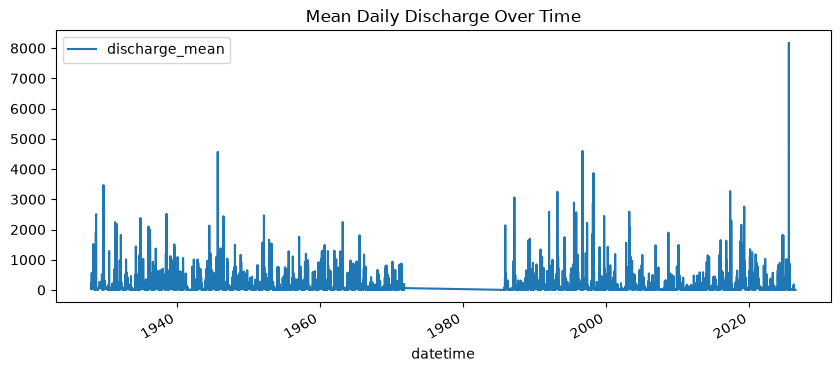

In [49]:
# Plot mean daily discharge over time
USGS_flow_data.plot(
    x="datetime",
    y="discharge_mean",
    figsize=(10, 4),
    title="Mean Daily Discharge Over Time"
);


**What should you notice?**

Look for high-flow events, long-term patterns, gaps, or values that seem unusual. What additional questions does this plot raise?


---
## 13. Save the processed dataset

The raw data file remains unchanged. We save the processed version separately so it can be reused later.


In [50]:
# Ensure the processed data folder exists
processed_fldr.mkdir(parents=True, exist_ok=True)

# Save the processed dataframe without the index
processed_file = processed_fldr / "USGS_Site02085000_Flow_Processed.csv"
USGS_flow_data.to_csv(processed_file, index=False)

print("Processed file saved to:", processed_file)


Processed file saved to: c:\Users\sjh104\EDE 700\ENV700\data\processed\USGS_Site02085000_Flow_Processed.csv


---
## Final reflection

Answer these questions before moving on:

1. What do you now know about this dataset that you did not know immediately after importing it?
2. Which fields would you trust for an initial analysis, and why?
3. Which fields require more investigation before analysis?
4. What did you change in the processed dataset?
5. What did you deliberately leave unchanged in the raw dataset?
